#Imports

In [5]:
import torch
from torch.utils.data import Dataset , DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
import torch.nn.functional as F

#Loading the data and getting few insights of it

In [6]:
words = open('Indian_Names.txt' , 'r').read().splitlines()
print("First 10 words :-")
words[:10]

First 10 words :-


['Aaban',
 'Aabharan',
 'Aabhas',
 'Aabhat',
 'Aabheer',
 'Abheer',
 'Aabher',
 'Aabi',
 'Aabilesh',
 'Aabir']

In [7]:
print("Total number of words :-" , len(words))
print(f"Longest word :- {max(words , key = len)}")
print(f"Shortest word :- {min(words , key = len)}")

Total number of words :- 53982
Longest word :- Parthadhwajagrasamvasine
Shortest word :- An


#Building the vocabulary

In [8]:
chars = sorted(list(set(''.join(words))))
if '.' in chars:
    chars.remove('.')

str_to_idx = {s:i+2 for i,s in enumerate(chars)}
str_to_idx['.'] = 1
str_to_idx['<PAD>'] = 0

idx_to_str = {i:s for s,i in str_to_idx.items()}

#Building training , testing and dev sets

In [9]:
class CustomDataset(Dataset):
  def __init__(self, words, str_to_idx):
    self.str_to_idx = str_to_idx
    self.X = []
    self.Y = []

    for w in words:
        # Add start and end tokens
        chars = ['.'] + list(w) + ['.']

        # Input sequence (e.g., .ram)
        x_seq = [self.str_to_idx[ch] for ch in chars[:-1]] # all except last
        # Target sequence (e.g., ram.)
        y_seq = [self.str_to_idx[ch] for ch in chars[1:]] # all except first

        self.X.append(x_seq)
        self.Y.append(y_seq)

  def __len__(self):
      return len(self.X)

  def __getitem__(self, idx):
      return self.X[idx], self.Y[idx]

In [10]:
def collate_seq(batch):
    # Unpack the batch of samples into separate lists for inputs (X) and targets (Y)
    # Each sample in 'batch' is expected to be a tuple (x_seq, y_seq)
    X, Y = zip(*batch)

    # Get original lengths of sequences before padding
    lengths = torch.tensor([len(x) for x in X], dtype=torch.long)

    # Convert each sequence in X and Y into a PyTorch tensor with long data type
    X = [torch.tensor(x, dtype=torch.long) for x in X]
    Y = [torch.tensor(y, dtype=torch.long) for y in Y]

    # Pad sequences in X to the same length, batch_first=True means the batch dimension comes first
    # padding_value=0 is used to fill shorter sequences to match the length of the longest sequence
    X_padded = pad_sequence(X, batch_first=True, padding_value=0)
    # Do the same for sequences in Y
    Y_padded = pad_sequence(Y, batch_first=True, padding_value=0)

    # Return the padded input, target tensors, and their original lengths
    return X_padded, Y_padded, lengths

In [11]:
import random

random.seed(42)
random.shuffle(words)

n = len(words)

n_train = int(0.8 * n)
n_dev   = int(0.9 * n)

train_words = words[:n_train]
dev_words   = words[n_train:n_dev]
test_words  = words[n_dev:]

In [12]:
train_dataset = CustomDataset(train_words, str_to_idx)
dev_dataset   = CustomDataset(dev_words,   str_to_idx)
test_dataset  = CustomDataset(test_words,  str_to_idx)

batch_size = 64 # how many independent sequences will we process in parallel?

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_seq)
dev_loader   = DataLoader(dev_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_seq)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_seq)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Dev dataset size: {len(dev_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of train batches: {len(train_loader)}")
print(f"Number of dev batches: {len(dev_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Train dataset size: 43185
Dev dataset size: 5398
Test dataset size: 5399
Number of train batches: 675
Number of dev batches: 85
Number of test batches: 85


#Defining a Decoder only Transformer Model



In [13]:
block_size = 256 # what is the maximum context length for predictions?
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2

In [14]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self , head_size):
      super().__init__()
      self.key = nn.Linear(n_embd, head_size, bias=False)
      self.query = nn.Linear(n_embd, head_size, bias=False)
      self.value = nn.Linear(n_embd, head_size, bias=False)
      self.register_buffer('tril' , torch.tril(torch.ones(block_size , block_size)))
      self.dropout = nn.Dropout(dropout)

    def forward(self , x):
      # input of size (batch, time-step, channels)
      # output of size (batch, time-step, head size)
      """Input to attention:
      (B, T, C) = (32, 10, 128)
      Output of one head:
      (B, T, head_size) = (32, 10, 32)"""

      """B = 32  → 32 names in one batch
          T = 10  → each name has 10 characters (padded if needed)
          C = 128 → each character is a 128-dim vector"""

      """C = 128 → each character is a 128-dim vector (full embedding)
      head_size = 32 → each attention head works on a 32-dim subspace of the embedding"""

      B,T,C = x.shape

      k = self.key(x) #(B , T , head_size)
      q = self.query(x) #(B , T , head_size)
      # compute attention scores ("affinities")
      wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 #(B, T, hs) @ (B, hs, T) -> (B, T, T)
      #Force the model to to stop looking at the future
      wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
      wei = F.softmax(wei, dim=-1) # (B, T, T)
      wei = self.dropout(wei)
      # perform the weighted aggregation of the values
      v = self.value(x) # (B,T,hs)
      out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
      return out

In [15]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel"""

    def __init__(self , num_heads , head_size):
      super().__init__()
      self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
      """After concatenation, size becomes bigger
      This layer brings it back to original embedding size"""
      self.proj = nn.Linear(n_embd , n_embd)
      self.dropout = nn.Dropout(dropout)

    def forward(self , x):
      out = torch.cat([h(x) for h in self.heads] , dim=-1)
      out = self.dropout(self.proj(out))
      return out

In [16]:
class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [17]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


In [18]:
class Transformer(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        return logits


#Training

In [19]:
EPOCHES = 1000
LR = 0.0003

In [20]:
vocab_size = len(str_to_idx)
model = Transformer()
m = model.to(device)

In [21]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
Loss = nn.CrossEntropyLoss(ignore_index=str_to_idx['<PAD>'])

In [22]:
step = []
loss_values = []
for Epoch in range(EPOCHES):
    # get a batch of data
    """for batch_idx, (xb, yb, lengths) in enumerate(train_loader):"""
    xb, yb, lengths = next(iter(train_loader))

    # move to device
    xb, yb = xb.to(device), yb.to(device);

    # evaluate the loss
    logits = model(xb) # Forward pass

    # Flatten logits and targets for CrossEntropyLoss
    B, T, C = logits.shape
    logits = logits.view(-1 , C)
    targets = yb.view(B * T)

    # Calculate loss, ignoring padding_value=0
    loss = Loss(logits, targets)

    optimizer.zero_grad(set_to_none=True) # Zero out gradients
    loss.backward() # Backpropagation
    optimizer.step() # Update weights

    step.append(Epoch)
    loss_values.append(loss.item())

    print(f"Epoch: {Epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 4.152275562286377
Epoch: 1 | Loss: 3.3135807514190674
Epoch: 2 | Loss: 3.204538345336914
Epoch: 3 | Loss: 3.0688624382019043
Epoch: 4 | Loss: 2.974196434020996
Epoch: 5 | Loss: 3.0147876739501953
Epoch: 6 | Loss: 2.9888453483581543
Epoch: 7 | Loss: 2.9171946048736572
Epoch: 8 | Loss: 2.9148776531219482
Epoch: 9 | Loss: 2.8686025142669678
Epoch: 10 | Loss: 2.837454319000244
Epoch: 11 | Loss: 2.7841334342956543
Epoch: 12 | Loss: 2.7397801876068115
Epoch: 13 | Loss: 2.7332119941711426
Epoch: 14 | Loss: 2.6506948471069336
Epoch: 15 | Loss: 2.6799185276031494
Epoch: 16 | Loss: 2.573693037033081
Epoch: 17 | Loss: 2.553927421569824
Epoch: 18 | Loss: 2.5390331745147705
Epoch: 19 | Loss: 2.519235134124756
Epoch: 20 | Loss: 2.5345702171325684
Epoch: 21 | Loss: 2.5327460765838623
Epoch: 22 | Loss: 2.4124326705932617
Epoch: 23 | Loss: 2.3496742248535156
Epoch: 24 | Loss: 2.354851722717285
Epoch: 25 | Loss: 2.266845226287842
Epoch: 26 | Loss: 2.312563419342041
Epoch: 27 | Loss: 2.3

In [23]:
avg_train_loss = sum(loss_values) / len(loss_values)
train_perplexity = torch.exp(torch.tensor(avg_train_loss))

print(f"Train Loss: {avg_train_loss:.4f}")
print(f"Train Perplexity: {train_perplexity:.4f}")

Train Loss: 2.0246
Train Perplexity: 7.5731


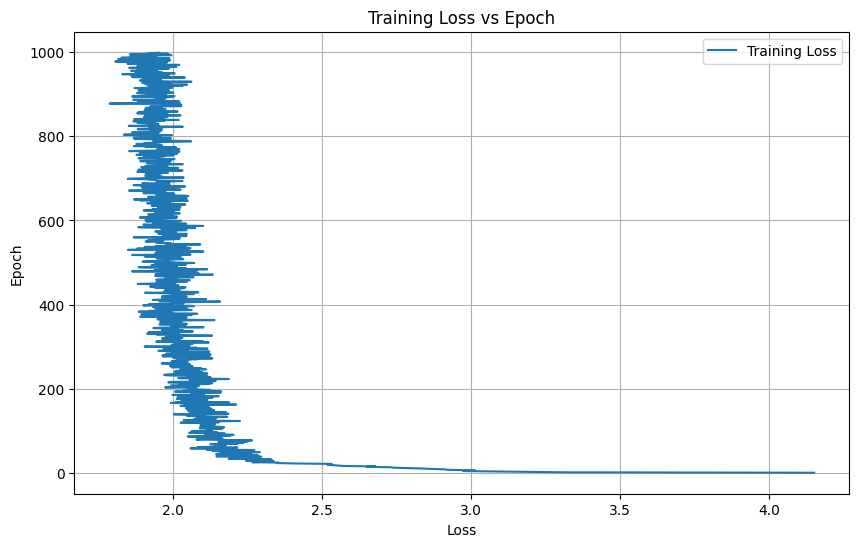

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(loss_values, step ,label='Training Loss')
plt.xlabel('Loss')
plt.ylabel('Epoch')
plt.title('Training Loss vs Epoch')
plt.grid(True)
plt.legend()
plt.savefig('training_loss_vs_epoch.png')
plt.show()

#Evaluation

In [25]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    total_tokens = 0

    with torch.no_grad():
        for xb, yb, lengths in data_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb) # (B, T, vocab_size)

            # Flatten logits and targets for CrossEntropyLoss
            B, T, C = logits.shape
            logits = logits.view(-1, C) # (B*T, vocab_size)
            targets = yb.view(-1) # (B*T)

            # Calculate loss, ignoring padding_value=0 as specified in criterion
            loss = criterion(logits, targets)

            # Accumulate loss weighted by the number of valid (non-padding) tokens in the batch
            # `lengths` already represents the valid length of each sequence.
            num_valid_tokens_in_batch = lengths.sum().item()
            total_loss += loss.item() * num_valid_tokens_in_batch
            total_tokens += num_valid_tokens_in_batch

    avg_loss = total_loss / total_tokens
    perplexity = torch.exp(torch.tensor(avg_loss)) # Perplexity is exp(average NLL)

    model.train() # Set model back to training mode
    return avg_loss, perplexity.item()


In [26]:
# Evaluate on development set
dev_loss, dev_perplexity = evaluate_model(model, dev_loader, Loss)
print(f"Dev Loss: {dev_loss:.4f}")
print(f"Dev Perplexity: {dev_perplexity:.4f}")

# Evaluate on test set
test_loss, test_perplexity = evaluate_model(model, test_loader, Loss)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Perplexity: {test_perplexity:.4f}")

Dev Loss: 1.9173
Dev Perplexity: 6.8027
Test Loss: 1.9096
Test Perplexity: 6.7502


#Sampling

In [27]:
def generate_names_from_transformer(model, str_to_idx, idx_to_str, block_size, num_samples=10, start_char='.', temperature=0.8, max_len=30, min_len=3, device='cpu'):
    model.eval() # Set model to evaluation mode
    generated_names = []

    start_idx = str_to_idx[start_char]
    end_idx = str_to_idx['.']
    pad_idx = str_to_idx['<PAD>']

    with torch.no_grad():
        for _ in range(num_samples):
            # Start sequence with the start character index
            current_sequence_indices = [start_idx]

            for _ in range(max_len):
                # Prepare the context for the model, limited by block_size
                # The model expects a sequence of indices to predict the next token
                context_for_model = current_sequence_indices[-block_size:]

                # Convert context to a tensor and move to the device
                x_tensor = torch.tensor([context_for_model], dtype=torch.long, device=device) # (1, T_context)

                # Get logits from the model
                # logits will be (1, T_context, vocab_size)
                logits = model(x_tensor)

                # We need the logits for the *next* token, which correspond to
                # the last token in the context's prediction
                logits_next_token = logits[:, -1, :] # (1, vocab_size)

                # Apply softmax to get probabilities and sample the next character
                probs = F.softmax(logits_next_token / temperature, dim=-1)
                next_char_idx = torch.multinomial(probs, num_samples=1).item()

                # Append the sampled character to the sequence
                current_sequence_indices.append(next_char_idx)

                # Check for termination conditions:
                # 1. If the end token is sampled and the name is long enough (excluding start/end tokens).
                if next_char_idx == end_idx and (len(current_sequence_indices) - 2) >= min_len:
                    break
                # 2. If the sequence length (including start token) exceeds the maximum allowed length.
                if len(current_sequence_indices) >= max_len + 1:
                    break

            # Convert the generated sequence of indices to a readable string
            # Filter out start_idx, end_idx, and padding token for the final name
            name_str = ''.join([idx_to_str[i] for i in current_sequence_indices if i not in [start_idx, end_idx, pad_idx]])
            generated_names.append(name_str)

    model.train() # Set model back to training mode
    return generated_names

# Generate some names using the trained Transformer model
print("\nGenerated Names:")
sampled_names = generate_names_from_transformer(
    model, str_to_idx, idx_to_str, block_size,
    num_samples=10, # Generate 10 names
    temperature=0.8, # Controls randomness of generation
    max_len=30,      # Max length of generated name
    min_len=3,       # Min length of generated name
    device=device
)

for name in sampled_names:
    print(name)


Generated Names:
Mulmer
Anuthani
Rubila
Riga
Aarishura
Muryath
Thaaamitha
Yarakswini
Prakumadya
Thanusha


#Saving the model

In [29]:
torch.save(model.state_dict(), 'transformer_model.pth')
print("Model saved to transformer_name_generator.pth")

Model saved to transformer_name_generator.pth
